In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [51]:
#Load dataset
housing = fetch_california_housing()

data = pd.DataFrame(housing.data, columns=housing.feature_names)
data["Price"] = housing.target

In [52]:
#sSelect one feature
X = data[['AveRooms']].values
y = data['Price'].values

In [53]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [54]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform (X_test)

In [55]:
w = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(X_train_scaled)

cost_history = []   # Store cost values

for i in range(epochs):

    y_pred = w * X_train_scaled.flatten() + b

    cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)

    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.6f}")

y_pred_gd = w * X_test_scaled.flatten() + b


Epoch 0, Cost = 2.814871
Epoch 100, Cost = 0.941435
Epoch 200, Cost = 0.690433
Epoch 300, Cost = 0.656804
Epoch 400, Cost = 0.652298
Epoch 500, Cost = 0.651694
Epoch 600, Cost = 0.651613
Epoch 700, Cost = 0.651603
Epoch 800, Cost = 0.651601
Epoch 900, Cost = 0.651601


In [57]:
print("Gradient Descent")
print("----------------")
print("Weight :", w)
print("Bias :", b)
print("MSE :", mean_squared_error(y_test, y_pred_gd))
print("R2 Score :", r2_score(y_test, y_pred_gd))

Gradient Descent
----------------
Weight : 0.18323090648660517
Bias : 2.0718574888450205
MSE : 1.292327655590046
R2 Score : 0.013798228607320828


In [58]:
#-----------------------------
#Normal Equation
#----------------------------
X_train_ne = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_ne = np.c_[np.ones((len(X_test), 1)), X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train

y_pred_ne = X_test_ne @ theta

In [59]:
print("\nNormal Equation")
print("Intercept:", theta[0])
print("Slpoe:", theta[1])
print("MSE:", mean_squared_error(y_test, y_pred_ne))
print("R2 Score:", r2_score(y_test, y_pred_ne))


Normal Equation
Intercept: 1.6547622685968417
Slpoe: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [60]:
#-----------------------------
#Sort values for smooth regression line
#-----------------------------
sort_axis = np.argsort(X_test.flatten())
X_sorted = X_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

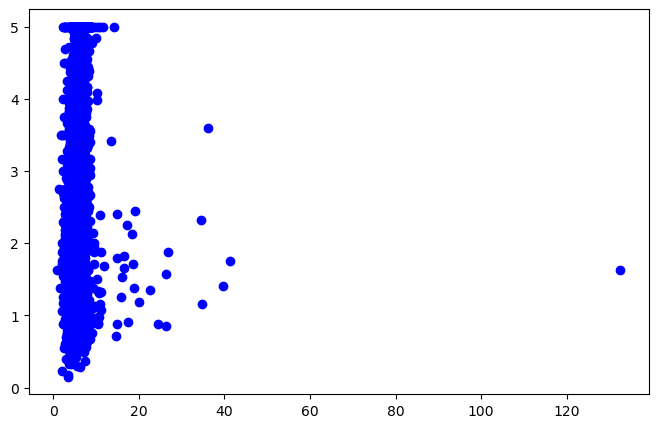

In [61]:
#-----------------------------
#Regression Line Visualization
#-----------------------------
#Sort X values for a smooth ine
index = np.argsort(X_test.flatten())
plt.figure(figsize=(8, 5))
#Scatter plot
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

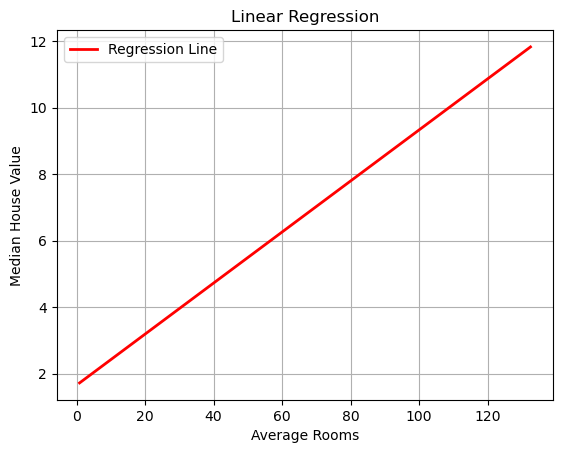

In [62]:
#Regression line
plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

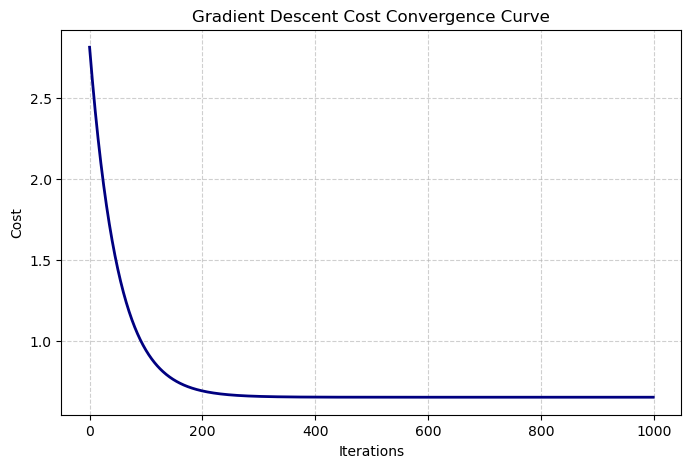

In [63]:
plt.figure(figsize=(8,5))

plt.plot(cost_history, color='navy', linewidth=2)

plt.title("Gradient Descent Cost Convergence Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()